# Predicting Heart disease using Machine Learning

<ol>
    <li><b>age:</b> displays the age of the individual.</li>
    <li><b>sex:</b> displays the gender of the individual using the following format :
    <ul>
        <li>1 = male</li>
        <li>0 = female</li>
        </ul></li>
    <li><b>cp (Chest-Pain Type):</b> displays the type of chest-pain experienced by the individual using the following format :
    <ul>
         <li>0 = typical angina</li>
         <li>1 = atypical angina</li>
         <li>2= non — anginal pain</li>
         <li>3 = asymptotic</li>
    </ul></li>
    <li><b>trestbps(Resting Blood Pressure):</b> displays the resting blood pressure value of an individual in mmHg (unit)</li>
    <li><b>chol(Serum Cholestrol):</b> displays the serum cholesterol in mg/dl (unit)</li>
    <li><b>fbs (Fasting Blood Sugar):</b> compares the fasting blood sugar value of an individual with 120mg/dl.
        <ul><li>If fasting blood sugar > 120mg/dl then : 1 (true) else : 0 (false)</li></ul></li>
    <li><b>restecg (Resting ECG):</b> displays resting electrocardiographic results
    <ul>
        <li>0 = normal</li>
        <li>1 = having ST-T wave abnormality</li>
        <li>2 = left ventricular hyperthrophy</li>
    </ul>
        </li>
    <li><b>thalach(Max Heart Rate Achieved):</b> displays the max heart rate achieved by an individual.</li>
    <li><b>exang (Exercise induced angina):</b><ul>
        <li>1 = yes</li>
        <li>0 = no</li>
        </ul>
    </li>
    <li><b>oldpeak (ST depression induced by exercise relative to rest):</b> displays the value which is an integer or float.</li>
    <li><b>slope (Peak exercise ST segment) :</b>
        <ul><li>0 = upsloping</li>
            <li>1 = flat</li>
            <li>2 = downsloping</li></ul></li>
    <li><b>ca (Number of major vessels (0–3) colored by flourosopy):</b> displays the value as integer or float.</li>
<li><b>thal :</b> displays the thalassemia (is an inherited blood disorder that causes your body to have less hemoglobin than normal) :
    <ul>
        <li>
            0 = normal</li>
        <li>1 = fixed defect</li>
        <li>2 = reversible defect</li></ul></li>
<li><b>target (Diagnosis of heart disease):</b> Displays whether the individual is suffering from heart disease or not :
    <ul><li>0 = absence</li>
        <li>1 = present.</li></ul></li></ol>


In [9]:
# Import all the tools we need

# Regular EDA(Exploratory data analysis) and plotting libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#We want our plots to appear inside the notebook
%matplotlib inline 

# Models from Scikit-Learn
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Model Evaluations
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import RocCurveDisplay

#Ignoring the warnings
import warnings
warnings.filterwarnings("ignore")

#Pandas-Profiling helps to build a widget that can be used to better visualise it
# Importing libraries
import numpy as np
import pandas as pd
from scipy.stats import mode
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
 
%matplotlib inline

### Importing the dataset

In [10]:
df=pd.read_csv('heart.csv')

### Shape of the dataset (Rows, Columns)

In [11]:
df.shape

(303, 14)

### Head of the dataset

In [12]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


<br><br>
# Exploratory Data analysis
<br>

### Renaming columns

In [13]:
df.rename(columns ={'age':'Age','sex':'Sex','cp':'Chest_pain','trestbps':'Resting_blood_pressure','chol':'Cholesterol','fbs':'Fasting_blood_sugar',
                    'restecg':'ECG_results','thalach':'Maximum_heart_rate','exang':'Exercise_induced_angina','oldpeak':'ST_depression','slope':'ST_slope','ca':'Major_vessels',
                   'thal':'Thalassemia_types','target':'Heart_disease'}, inplace = True)

In [14]:
# View of the Renamed Dataframe
df.head()

,Age,Sex,Chest_pain,Resting_blood_pressure,Cholesterol,Fasting_blood_sugar,ECG_results,Maximum_heart_rate,Exercise_induced_angina,ST_depression,ST_slope,Major_vessels,Thalassemia_types,Heart_disease
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


### Information about the data

In [15]:
df1 = df.copy()                               # Create copy of DataFrame
df1['ST_depression'] = df1['ST_depression'].astype(int)         # Transform float to integer
print(df1) 

     Age  Sex  Chest_pain  Resting_blood_pressure  Cholesterol  \
0     63    1           3                     145          233   
1     37    1           2                     130          250   
2     41    0           1                     130          204   
3     56    1           1                     120          236   
4     57    0           0                     120          354   
..   ...  ...         ...                     ...          ...   
298   57    0           0                     140          241   
299   45    1           3                     110          264   
300   68    1           0                     144          193   
301   57    1           0                     130          131   
302   57    0           1                     130          236   

     Fasting_blood_sugar  ECG_results  Maximum_heart_rate  \
0                      1            0                 150   
1                      0            1                 187   
2                      0

In [16]:
df=df1

In [17]:
list(df.columns.values)

['Age',
 'Sex',
 'Chest_pain',
 'Resting_blood_pressure',
 'Cholesterol',
 'Fasting_blood_sugar',
 'ECG_results',
 'Maximum_heart_rate',
 'Exercise_induced_angina',
 'ST_depression',
 'ST_slope',
 'Major_vessels',
 'Thalassemia_types',
 'Heart_disease']

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Age                      303 non-null    int64
 1   Sex                      303 non-null    int64
 2   Chest_pain               303 non-null    int64
 3   Resting_blood_pressure   303 non-null    int64
 4   Cholesterol              303 non-null    int64
 5   Fasting_blood_sugar      303 non-null    int64
 6   ECG_results              303 non-null    int64
 7   Maximum_heart_rate       303 non-null    int64
 8   Exercise_induced_angina  303 non-null    int64
 9   ST_depression            303 non-null    int32
 10  ST_slope                 303 non-null    int64
 11  Major_vessels            303 non-null    int64
 12  Thalassemia_types        303 non-null    int64
 13  Heart_disease            303 non-null    int64
dtypes: int32(1), int64(13)
memory usage: 32.1 KB


### Description about the dataset

In [19]:
df.describe()

,Age,Sex,Chest_pain,Resting_blood_pressure,Cholesterol,Fasting_blood_sugar,ECG_results,Maximum_heart_rate,Exercise_induced_angina,ST_depression,ST_slope,Major_vessels,Thalassemia_types,Heart_disease
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,0.765677,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.070933,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.000000,2.000000,4.000000,3.000000,1.000000


### Are there any missing values?

In [20]:
df.isna().sum() 

Age                        0
Sex                        0
Chest_pain                 0
Resting_blood_pressure     0
Cholesterol                0
Fasting_blood_sugar        0
ECG_results                0
Maximum_heart_rate         0
Exercise_induced_angina    0
ST_depression              0
ST_slope                   0
Major_vessels              0
Thalassemia_types          0
Heart_disease              0
dtype: int64

### Correlation matrix & Matrix Visualisation

In [21]:
df.corr()

,Age,Sex,Chest_pain,Resting_blood_pressure,Cholesterol,Fasting_blood_sugar,ECG_results,Maximum_heart_rate,Exercise_induced_angina,ST_depression,ST_slope,Major_vessels,Thalassemia_types,Heart_disease
Age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.178396,-0.168814,0.276326,0.068001,-0.225439
Sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.089604,-0.030711,0.118261,0.210041,-0.280937
Chest_pain,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.180783,0.119717,-0.181053,-0.161736,0.433798
Resting_blood_pressure,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.190276,-0.121475,0.101389,0.062210,-0.144931
Cholesterol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.035479,-0.004038,0.070511,0.098803,-0.085239
Fasting_blood_sugar,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.022088,-0.059894,0.137979,-0.032019,-0.028046
ECG_results,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.055906,0.093045,-0.072042,-0.011981,0.137230
Maximum_heart_rate,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.327627,0.386784,-0.213177,-0.096439,0.421741
Exercise_induced_angina,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.271144,-0.257748,0.115739,0.206754,-0.436757
ST_depression,0.178396,0.089604,-0.180783,0.190276,0.035479,0.022088,-0.055906,-0.327627,0.271144,1.000000,-0.555175,0.232167,0.198263,-0.423572


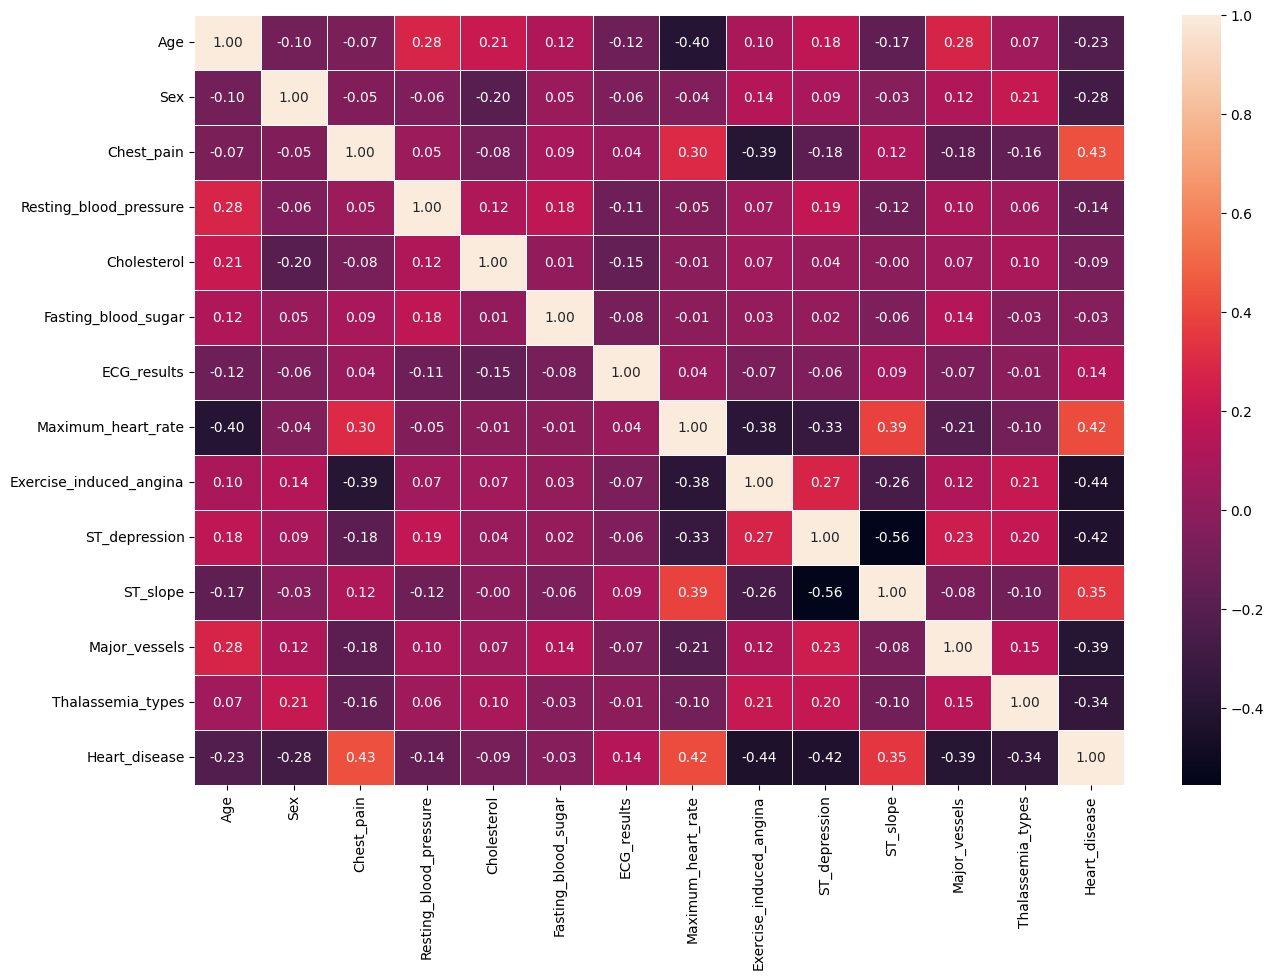

In [22]:
# Let's make our correlation matrix visual
corr_matrix=df.corr()
fig,ax=plt.subplots(figsize=(15,10))
ax=sns.heatmap(corr_matrix,
               annot=True,
               linewidths=0.5,
               fmt=".2f"
              )

In [23]:
X=df.drop(['Heart_disease'],axis=1)
y=df['Heart_disease']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

## 1. Logistic Regression

In [24]:
lr=LogisticRegression()

In [25]:
lr.fit(X_train,y_train)

LogisticRegression()

In [26]:
#Training score

lr.score(X_train,y_train)

0.859504132231405

In [27]:
#Prediction of the test variable

lr_y_preds=lr.predict(X_test)

In [28]:
#Testing accuracy

lr.score(X_test,y_test)

0.8852459016393442

### Confusion Matrix

In [29]:
sns.set(font_scale=1.5)

def plot_conf_mat(y_test,y_preds):
    """
    Plots a nice looking confusion matrix using Seaborn's heatmap
    """
    fig,ax=plt.subplots(figsize=(3,3))
    ax=sns.heatmap(confusion_matrix(y_test,y_preds),annot=True,cbar=False)
    plt.xlabel("True Label")
    plt.ylabel("Predicted Label")


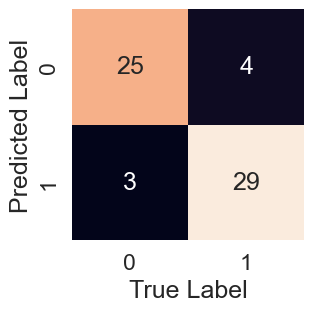

In [30]:
plot_conf_mat(y_test,lr_y_preds)

### Classification Report

In [31]:
print(classification_report(y_test,lr_y_preds))

              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



## 2. K-Nearest Neighbour

In [32]:
knn=KNeighborsClassifier()

In [33]:
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [34]:
#Training score

knn.score(X_train,y_train)

0.7603305785123967

In [35]:
#Prediction of the test variable

knn_y_preds=knn.predict(X_test)

In [36]:
#Testing accuracy

knn.score(X_test,y_test)

0.6885245901639344

### Confusion Matrix

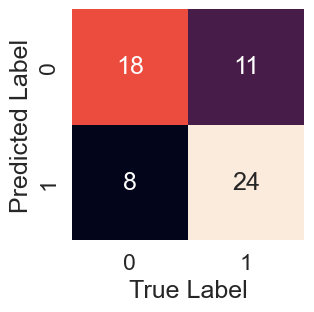

In [37]:
plot_conf_mat(y_test,knn_y_preds)

### Classification Report

In [38]:
print(classification_report(y_test,knn_y_preds))

              precision    recall  f1-score   support

           0       0.69      0.62      0.65        29
           1       0.69      0.75      0.72        32

    accuracy                           0.69        61
   macro avg       0.69      0.69      0.69        61
weighted avg       0.69      0.69      0.69        61



## 3. Random Forest

In [39]:
rf=RandomForestClassifier()

In [40]:
rf.fit(X_train,y_train)

RandomForestClassifier()

In [41]:
#Training score

rf.score(X_train,y_train)

1.0

In [42]:
#Prediction of the test variable

rf_y_preds=rf.predict(X_test)

In [43]:
#Testing accuracy

rf.score(X_test,y_test)

0.8360655737704918

### Confusion Matrix

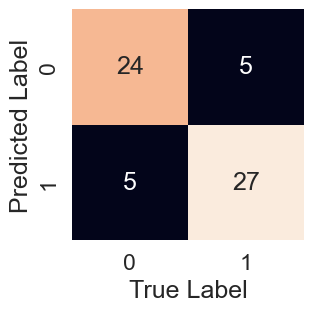

In [44]:
plot_conf_mat(y_test,rf_y_preds)

### Classification Report

In [45]:
print(classification_report(y_test,rf_y_preds))

              precision    recall  f1-score   support

           0       0.83      0.83      0.83        29
           1       0.84      0.84      0.84        32

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



In [46]:
svm = SVC()

In [47]:
svm.fit(X_train,y_train)

SVC()

In [48]:
svm.score(X_train,y_train)

0.6570247933884298

In [49]:
preds=svm.predict(X_test)
svm.score(X_test,y_test)

0.7049180327868853

In [50]:
model_scores={'Logistic Regression':lr.score(X_test,y_test),
             'KNN':knn.score(X_test,y_test),
             'Random Forest':rf.score(X_test,y_test),
             'svm':svm.score(X_test,y_test)}

In [51]:
model_scores

{'Logistic Regression': 0.8852459016393442,
 'KNN': 0.6885245901639344,
 'Random Forest': 0.8360655737704918,
 'svm': 0.7049180327868853}

## Model Comparison

In [52]:
#Based on accuracy
model_compare=pd.DataFrame(model_scores,index=['accuracy'])
model_compare

,Logistic Regression,KNN,Random Forest,svm
accuracy,0.885246,0.688525,0.836066,0.704918


In [53]:
from joblib import Parallel, delayed
import joblib
#joblib.dump(lr, 'heart.sav')

<Axes: >

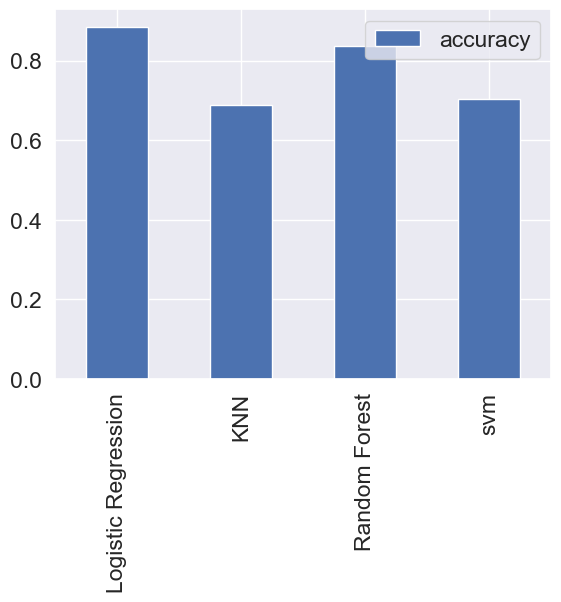

In [54]:
model_compare.T.plot(kind='bar') # (T is here for transpose)

In [55]:
import pickle
pickle.dump(lr,open('heart_disease.pkl','wb'))